In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def get_plot(data, title, legend_position="lower right", figsize=(8,6)):
    df = pd.DataFrame(data)


    # Get unique groups and predictors
    groups = df['Group'].unique()
    predictors = df['Measurement'].unique()
    n_groups = len(groups)
    n_predictors = len(predictors)


    # Set bar width and positions
    bar_width = 0.4
    group_spacing = 2
    x = np.arange(n_groups) * group_spacing


    fig, ax = plt.subplots(figsize=figsize)

    maxval = df['DeltaAIC'].abs().max()
    shift = maxval / 40
    shiftplus = shift*5

    # Plot bars for each predictor
    for i, predictor in enumerate(predictors):
        subset: pd.DataFrame = df[df['Measurement'] == predictor]
        positions = x + i * bar_width - (bar_width * (n_predictors-1) / 2)
        bars = ax.bar(positions, subset['DeltaAIC'], bar_width, label=predictor)
        # Add significance codes and effect sizes
        if 'Coefficient' in subset.columns:
            for pos, val, sig, eff in zip(positions, subset['DeltaAIC'], subset['Significance'], subset['Coefficient']):
                if val < 0:
                    ax.text(pos, val - shift, sig, ha='center', va='top', fontsize=10)
                    ax.text(pos, val - shiftplus, f"{eff:.2f}", ha='center', va='bottom', fontsize=9, color="black")
                else:
                    ax.text(pos, val + shift, sig, ha='center', va='bottom', fontsize=10)
                    ax.text(pos, val + shiftplus, f"{eff:.2f}", ha='center', va='bottom', fontsize=9, color="black")
        else:
            for pos, val, sig in zip(positions, subset['DeltaAIC'], subset['Significance']):
                if val < 0:
                    ax.text(pos, val - shift, sig, ha='center', va='top', fontsize=10)
                else:
                    ax.text(pos, val + shift, sig, ha='center', va='bottom', fontsize=10)


    # Formatting
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0] - shiftplus, ylim[1])
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylabel("ΔAIC")
    ax.set_title(title)
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.legend(title="Measurement", loc=legend_position) #, bbox_to_anchor=(0, -0.25))
    ax.axhline(0, color='black', linewidth=0.8)

    return fig, ax

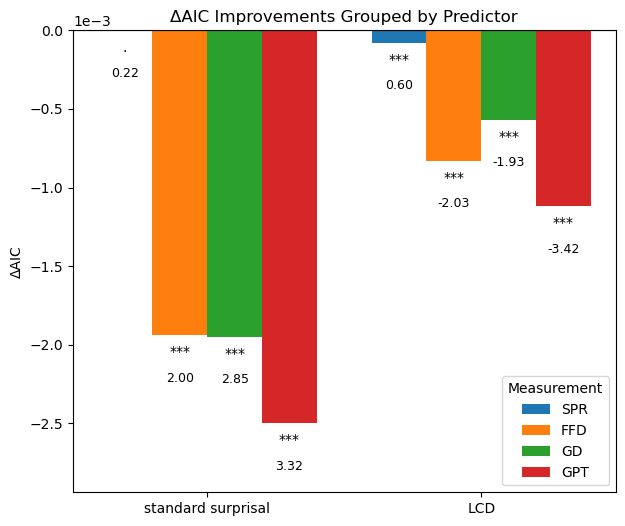

In [3]:
# Example input data (with effect sizes added)
data = {
'Group': ['standard surprisal', 'standard surprisal', 'standard surprisal', 'standard surprisal',
            #'structural', 'structural', 'structural', 'structural',
            'LCD', 'LCD', 'LCD', 'LCD'],
'Measurement': ['SPR', 'FFD', 'GD', 'GPT',
                #'SPR', 'FFD', 'GD', 'GPT',
                'SPR', 'FFD', 'GD', 'GPT'],
'DeltaAIC': [-4.10e-6, -1.94e-3, -1.95e-3, -2.50e-3,
#-2.13e-6, -3.45e-4, -3.05e-4, -1.93e-4,
-8.09e-5, -8.33e-4, -5.71e-4, -1.12e-3],
'Significance': ['.', '***', '***', '***',
#'.', '***', '***', '**',
'***', '***', '***', '***'],
'Coefficient': [0.22, 2.00, 2.85, 3.32,
#-0.14, 0.94, 1.30, 0.07,
0.6, -2.03, -1.93, -3.42]
}

plot = get_plot(data, "ΔAIC Improvements Grouped by Predictor", figsize=(7,6))[0]
#plt.tight_layout()
plt.show()

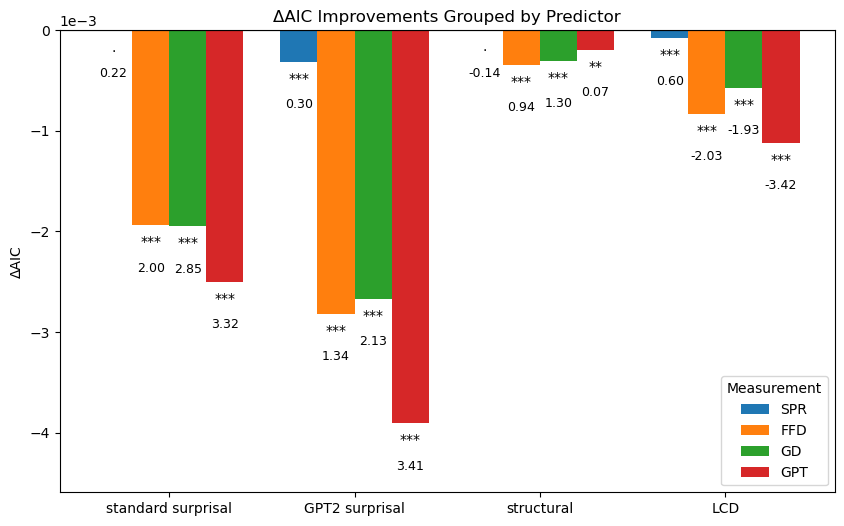

In [6]:
# Example input data (with effect sizes added)
data = {
'Group': ['standard surprisal', 'standard surprisal', 'standard surprisal', 'standard surprisal']
        + ["GPT2 surprisal"] * 4
        + ['structural', 'structural', 'structural', 'structural',
            'LCD', 'LCD', 'LCD', 'LCD'],
'Measurement': ['SPR', 'FFD', 'GD', 'GPT']*4,
'DeltaAIC': [-4.10e-6, -1.94e-3, -1.95e-3, -2.50e-3,
-3.18e-4, -2.82e-3, -2.67e-3, -3.91e-3,
-2.13e-6, -3.45e-4, -3.05e-4, -1.93e-4,
-8.09e-5, -8.33e-4, -5.71e-4, -1.12e-3],
'Significance': ['.', '***', '***', '***',
'***', '***', '***', '***',
'.', '***', '***', '**',
'***', '***', '***', '***'],
'Coefficient': [0.22, 2.00, 2.85, 3.32,
0.30, 1.34, 2.13, 3.41,
-0.14, 0.94, 1.30, 0.07,
0.6, -2.03, -1.93, -3.42]
}

plot = get_plot(data, "ΔAIC Improvements Grouped by Predictor", figsize=(10,6))[0]
#plt.tight_layout()
plt.show()

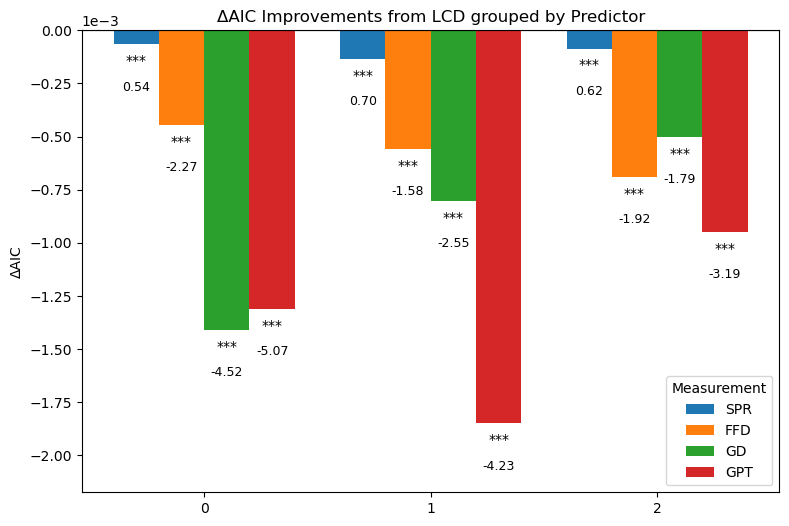

In [8]:
# Example input data (with effect sizes added)
data = {
'Group':  ['0']*4
        + ['1']*4
        + ['2']*4,
'Measurement': ['SPR', 'FFD', 'GD', 'GPT']*3,
'DeltaAIC': [
    -6.61e-5, -4.44e-4, -1.41e-3, -1.31e-3,
    -1.35e-4, -5.57e-4, -8.02e-4, -1.85e-3,
    -8.58e-5, -6.90e-4, -5.03e-4, -9.49e-4],
'Significance': [
    '***', '***', '***', '***',
    '***', '***', '***', '***',
    '***', '***', '***', '***'],
'Coefficient': [
    0.54, -2.27, -4.52, -5.07,
    0.70, -1.58, -2.55, -4.23,
    0.62, -1.92, -1.79, -3.19]
}

plot = get_plot(data, "ΔAIC Improvements from LCD grouped by Predictor", figsize=(9,6))[0]
#plt.tight_layout()
plt.show()

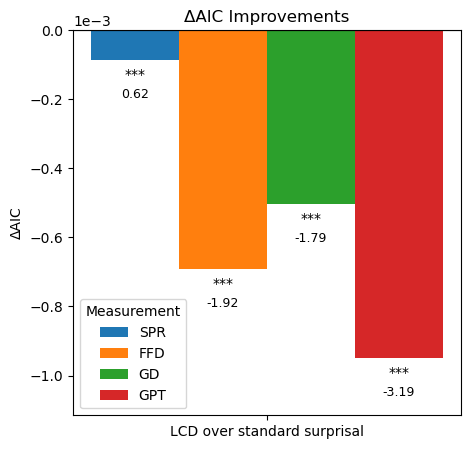

In [4]:
# Example input data (with effect sizes added)
data = {
'Group': ['LCD over standard surprisal', 'LCD over standard surprisal', 'LCD over standard surprisal', 'LCD over standard surprisal',],
'Measurement': ['SPR', 'FFD', 'GD', 'GPT'],
'DeltaAIC': [-8.58e-5, -6.90e-4, -5.03e-4, -9.49e-4],
'Significance': ['***', '***', '***', '***'],
'Coefficient': [0.62, -1.92, -1.79, -3.19]
}

plot, fig = get_plot(data, "ΔAIC Improvements", "lower left", (5,5))
#plt.tight_layout()
plt.show()

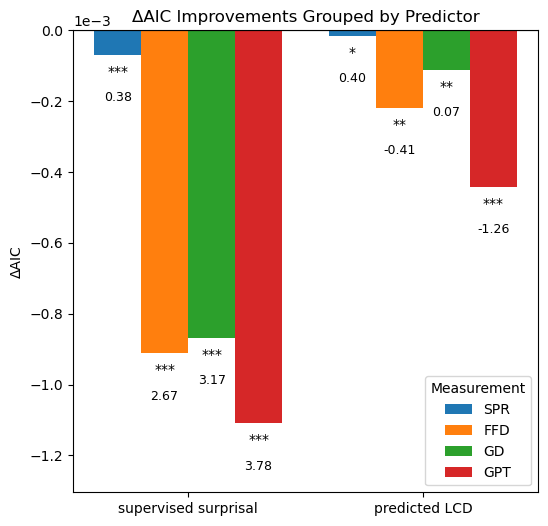

In [5]:
# Example input data (with effect sizes added)
data = {
'Group': ['supervised surprisal', 'supervised surprisal', 'supervised surprisal', 'supervised surprisal',
            'predicted LCD', 'predicted LCD', 'predicted LCD', 'predicted LCD'],
'Measurement': ['SPR', 'FFD', 'GD', 'GPT',
                'SPR', 'FFD', 'GD', 'GPT'],
'DeltaAIC': [-7.04e-5, -9.12e-4, -8.68e-4, -1.11e-3,
-1.67e-5, -2.20e-4, -1.12e-4, -4.42e-4,],
'Significance': ['***', '***', '***', '***',
'*', '**', '**', '***',],
'Coefficient': [0.38, 2.67, 3.17, 3.78,
                0.40, -0.41, 0.07, -1.26]
}

plot = get_plot(data, "ΔAIC Improvements Grouped by Predictor", figsize=(6,6))[0]
#plt.tight_layout()
plt.show()

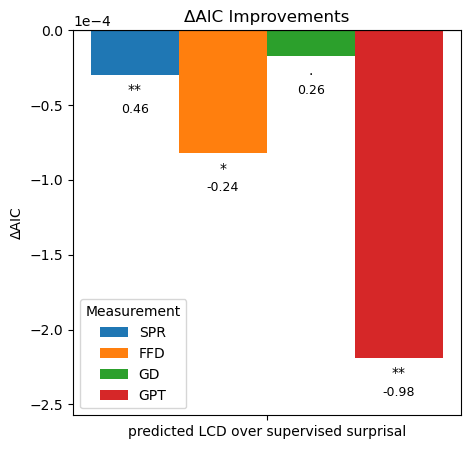

In [6]:
# Example input data (with effect sizes added)
data = {
'Group': ['predicted LCD over supervised surprisal']*4,
'Measurement': ['SPR', 'FFD', 'GD', 'GPT'],
'DeltaAIC': [-2.97e-5, -8.22e-5, -1.7e-5, -2.19e-4],
'Significance': ['**', '*', '.', '**'],
'Coefficient': [0.46, -0.24, 0.26, -0.98]
}

plot, fig = get_plot(data, "ΔAIC Improvements", "lower left", (5,5))
#plt.tight_layout()
plt.show()

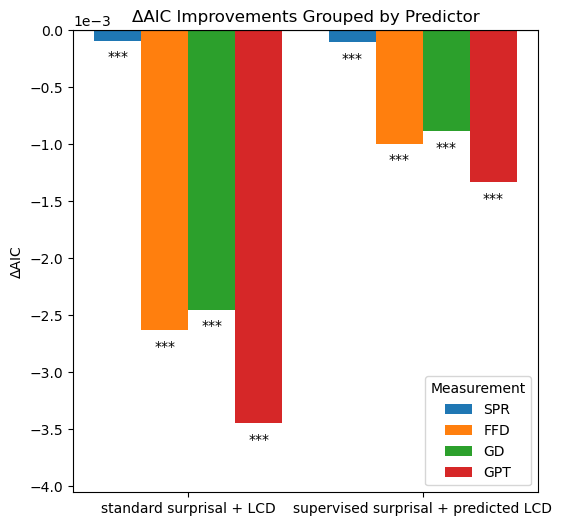

In [7]:
# Example input data (with effect sizes added)
data = {
'Group': ['standard surprisal + LCD']*4
            + ['supervised surprisal + predicted LCD']*4,
'Measurement': ['SPR', 'FFD', 'GD', 'GPT']*2,
'DeltaAIC': [-8.99e-5, -2.63e-3, -2.45e-3, -3.45e-3,
-1.00e-4, -9.94e-4, -8.85e-4, -1.33e-3],
'Significance': ['***', '***', '***', '***',
'***', '***', '***', '***',],
#'Coefficient': [0.38, 2.67, 3.17, 3.78,
#                0.40, -0.41, 0.07, -1.26]
}

plot = get_plot(data, "ΔAIC Improvements Grouped by Predictor", figsize=(6,6))[0]
#plt.tight_layout()
plt.show()

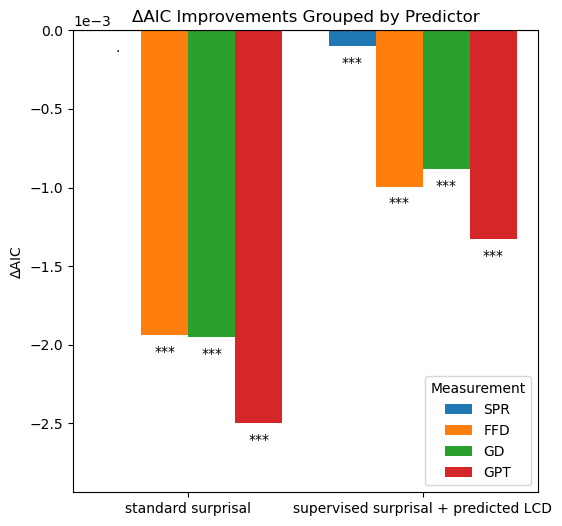

In [8]:
# Example input data (with effect sizes added)
data = {
'Group': ['standard surprisal']*4
            + ['supervised surprisal + predicted LCD']*4,
'Measurement': ['SPR', 'FFD', 'GD', 'GPT']*2,
'DeltaAIC': [-4.10e-6, -1.94e-3, -1.95e-3, -2.50e-3,
-1.00e-4, -9.94e-4, -8.85e-4, -1.33e-3],
'Significance': ['.', '***', '***', '***',
'***', '***', '***', '***',],
#'Coefficient': [0.38, 2.67, 3.17, 3.78,
#                0.40, -0.41, 0.07, -1.26]
}

plot = get_plot(data, "ΔAIC Improvements Grouped by Predictor", figsize=(6,6))[0]
#plt.tight_layout()
plt.show()

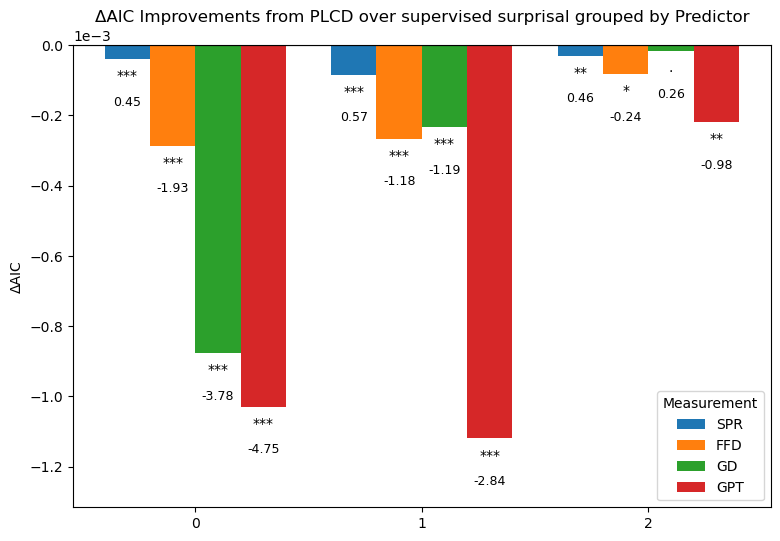

In [9]:
# Example input data (with effect sizes added)
data = {
'Group':  ['0']*4
        + ['1']*4
        + ['2']*4,
'Measurement': ['SPR', 'FFD', 'GD', 'GPT']*3,
'DeltaAIC': [
    -3.97e-5, -2.87e-4, -8.77e-4, -1.03e-3,
    -8.40e-5, -2.66e-4, -2.34e-4, -1.12e-3,
    -2.97e-5, -8.22e-5, -1.70e-5, -2.19e-4],
'Significance': [
    '***', '***', '***', '***',
    '***', '***', '***', '***',
    '**', '*', '.', '**'],
'Coefficient': [
    0.45, -1.93, -3.78, -4.75,
    0.57, -1.18, -1.19, -2.84,
    0.46, -0.24, 0.26, -0.98]
}

plot = get_plot(data, "ΔAIC Improvements from PLCD over supervised surprisal grouped by Predictor", figsize=(9,6))[0]
#plt.tight_layout()
plt.show()

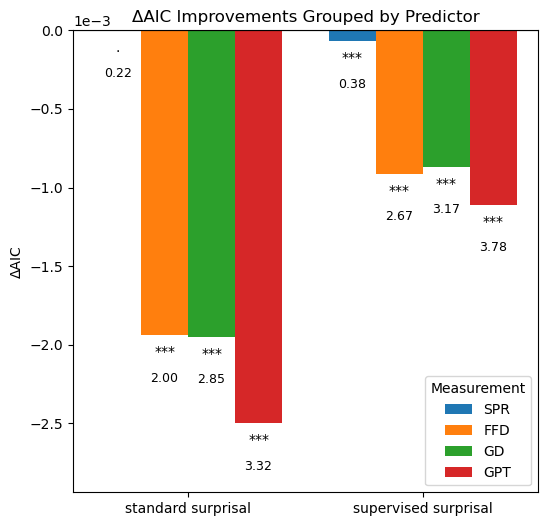

In [10]:
# Example input data (with effect sizes added)
data = {
'Group': ['standard surprisal']*4
            + ['supervised surprisal']*4,
'Measurement': ['SPR', 'FFD', 'GD', 'GPT']*2,
'DeltaAIC': [-4.10e-6, -1.94e-3, -1.95e-3, -2.50e-3,
-7.04e-5, -9.12e-4, -8.68e-4, -1.11e-3],
'Significance': ['.', '***', '***', '***',
'***', '***', '***', '***',],
'Coefficient': [0.22, 2.00, 2.85, 3.32,
                0.38, 2.67, 3.17, 3.78]
}

plot = get_plot(data, "ΔAIC Improvements Grouped by Predictor", figsize=(6,6))[0]
#plt.tight_layout()
plt.show()


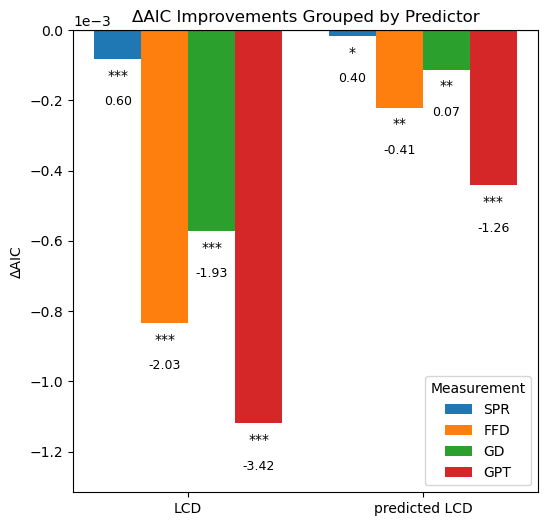

In [12]:
# Example input data (with effect sizes added)
data = {
'Group': ['LCD', 'LCD', 'LCD', 'LCD',
            'predicted LCD', 'predicted LCD', 'predicted LCD', 'predicted LCD'],
'Measurement': ['SPR', 'FFD', 'GD', 'GPT',
                'SPR', 'FFD', 'GD', 'GPT'],
'DeltaAIC': [-8.09e-5, -8.33e-4, -5.71e-4, -1.12e-3,
-1.67e-5, -2.20e-4, -1.12e-4, -4.42e-4,],
'Significance': ['***', '***', '***', '***',
'*', '**', '**', '***',],
'Coefficient': [0.60, -2.03, -1.93, -3.42,
                0.40, -0.41, 0.07, -1.26]
}

plot = get_plot(data, "ΔAIC Improvements Grouped by Predictor", figsize=(6,6))[0]
#plt.tight_layout()
plt.show()
